<a href="https://colab.research.google.com/github/jfodera/College-Exam-Hub/blob/main/NBA_Shot_Pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import os
import glob
import pandas as pd

## Introduction

Basketball, particularly the NBA, is a sport rich in data, with every action on the court meticulously recorded. Understanding the factors that contribute to a successful shot is a critical aspect for coaches, analysts, and players alike, influencing strategic decisions, player development, and game outcomes. The motivation behind this project is to leverage this wealth of data to gain insights into shot predictability and the evolving dynamics of the game.

This project addresses the problem of accurately predicting whether an NBA shot will be made or missed. Given the fast-paced and dynamic nature of basketball, even marginal improvements in shot prediction can yield significant analytical advantages. We aim to build robust predictive models that can identify key determinants of shot success, considering both contextual game-time factors and inherent player attributes.

The primary objectives of this project are twofold: first, to develop and evaluate various machine learning and deep learning models for binary shot outcome prediction; and second, to investigate the temporal stability and relevance of these models across different NBA seasons. The scope of this analysis spans from the 2004 to 2024 NBA seasons, utilizing a comprehensive dataset that combines shot-by-shot data with player biometric information.

Our methodology involves several key stages: initial data retrieval from public Kaggle repositories, merging disparate datasets (NBA shot data and player biometric data), followed by an extensive exploratory data analysis to understand data distributions and relationships. Feature engineering focuses on creating relevant predictors and addressing issues like multicollinearity and data leakage by dropping redundant spatial features, rare action types, and sensitive `DRAFT_YEAR` and `EVENT_TYPE` columns. Data is then preprocessed using one-hot encoding and standardized for model compatibility. We employ a range of models, including Logistic Regression, Random Forest, XGBoost, scikit-learn's Multi-Layer Perceptron (MLP), and a custom PyTorch Neural Network, with hyperparameters tuned using RandomizedSearchCV and Optuna. Finally, a temporal analysis using LightGBM is performed to assess how model performance changes when trained on different historical windows of data, providing insights into the concept of 'recency bias' in basketball analytics.

## Data Retrieval

### Pulling NBA Shots with Player infromation attached from existing [Kaggle Repo](https://www.kaggle.com/datasets/mexwell/nba-shots) (2004-2024)

In [2]:
shotsKagglePath = kagglehub.dataset_download("mexwell/nba-shots")

print("Path to dataset files:", shotsKagglePath)

shotsKagglePath = "/kaggle/input/nba-shots"
shotsCsvFiles = glob.glob(os.path.join(shotsKagglePath, "*.csv"))
print(shotsCsvFiles)

Using Colab cache for faster access to the 'nba-shots' dataset.
Path to dataset files: /kaggle/input/nba-shots
['/kaggle/input/nba-shots/NBA_2022_Shots.csv', '/kaggle/input/nba-shots/NBA_2021_Shots.csv', '/kaggle/input/nba-shots/NBA_2019_Shots.csv', '/kaggle/input/nba-shots/NBA_2020_Shots.csv', '/kaggle/input/nba-shots/NBA_2006_Shots.csv', '/kaggle/input/nba-shots/NBA_2009_Shots.csv', '/kaggle/input/nba-shots/NBA_2016_Shots.csv', '/kaggle/input/nba-shots/NBA_2011_Shots.csv', '/kaggle/input/nba-shots/NBA_2004_Shots.csv', '/kaggle/input/nba-shots/NBA_2015_Shots.csv', '/kaggle/input/nba-shots/NBA_2013_Shots.csv', '/kaggle/input/nba-shots/NBA_2014_Shots.csv', '/kaggle/input/nba-shots/NBA_2008_Shots.csv', '/kaggle/input/nba-shots/NBA_2023_Shots.csv', '/kaggle/input/nba-shots/NBA_2024_Shots.csv', '/kaggle/input/nba-shots/NBA_2007_Shots.csv', '/kaggle/input/nba-shots/NBA_2010_Shots.csv', '/kaggle/input/nba-shots/NBA_2012_Shots.csv', '/kaggle/input/nba-shots/NBA_2017_Shots.csv', '/kaggle/input

### Retrieving Player specific Biometric Data




#### Our Process
- There were no existing Data sets that matched our needs, so we created our own by making use of the [nba_api](https://github.com/swar/nba_api)
- We created our own public [Kaggle repo](https://www.kaggle.com/datasets/joefodera/biometric-attributes-of-nba-players-per-season/data) to pull from to preserve consistency of our colab final project file
  - descriptions of how we retrieved this section of data and how we worked with the API to retrieve exactly what we needed can be found in this colab file


In [3]:
playerKagglePath = kagglehub.dataset_download("joefodera/biometric-attributes-of-nba-players-per-season")

print("Path to dataset files:", playerKagglePath)

playerKagglePath = "/kaggle/input/biometric-attributes-of-nba-players-per-season"
playerCsvFiles = glob.glob(os.path.join(playerKagglePath, "*.csv"))


Using Colab cache for faster access to the 'biometric-attributes-of-nba-players-per-season' dataset.
Path to dataset files: /kaggle/input/biometric-attributes-of-nba-players-per-season


### Merging and Anonymizing NBA_shots and NBA_Players


Note that based on the dataset documentation each file maps to a season with the following constructs:
- Both `NBA_2004_Shots.csv` and `NBA_2004_Players.csv` are from the 2003-2004 NBA Season



In [4]:
allPlayerDataFrames = []

for f in playerCsvFiles:
    df = pd.read_csv(f)

    allPlayerDataFrames.append(df)
allShotDataFrames = []

for f in shotsCsvFiles:
    df = pd.read_csv(f)
    allShotDataFrames.append(df)

In [5]:
#Shots Structure:
## SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,HOME_TEAM,AWAY_TEAM,EVENT_TYPE,SHOT_MADE,ACTION_TYPE,SHOT_TYPE,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
#Players Structure:
##PLAYER_ID,PLAYER_NAME,AGE,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,DRAFT_YEAR,SEASON_1


# Sort the dataframe lists by years so the indicies align
## .iloc[0] - looks at season from first row in DF
allShotDataFramesSort = sorted(allShotDataFrames,key=lambda x: x['SEASON_1'].iloc[0])
allPlayerDataFramesSort = sorted(allPlayerDataFrames,key=lambda x: x['SEASON_1'].iloc[0])

# # Check if indicies are aligned BEFORE dropping columns
# for i in range(len(allShotDataFramesSort)):
#   print(allShotDataFramesSort[i]['SEASON_1'].iloc[0])
#   print(allPlayerDataFramesSort[i]['SEASON_1'].iloc[0], '\n\n')

# Things to drop
dropFromPlayers = ['PLAYER_NAME']
dropFromShots = ['SEASON_1','SEASON_2','TEAM_ID','TEAM_NAME', 'PLAYER_NAME','GAME_DATE','GAME_ID','HOME_TEAM','AWAY_TEAM']

for i in range(len(allShotDataFramesSort)):
  allShotDataFramesSort[i] = allShotDataFramesSort[i].drop(columns = dropFromShots)
  allPlayerDataFramesSort[i] = allPlayerDataFramesSort[i].drop(columns = dropFromPlayers)

# # Check if correct columns have been successfully dropped
print(allShotDataFramesSort[0].head())
print(allPlayerDataFramesSort[0].head())


   PLAYER_ID POSITION_GROUP POSITION   EVENT_TYPE  SHOT_MADE  \
0        977              G       SG    Made Shot       True   
1        757              G       PG    Made Shot       True   
2        977              G       SG  Missed Shot      False   
3        757              G       PG    Made Shot       True   
4        757              G       PG  Missed Shot      False   

          ACTION_TYPE       SHOT_TYPE         BASIC_ZONE         ZONE_NAME  \
0           Jump Shot  3PT Field Goal  Above the Break 3  Left Side Center   
1  Driving Layup Shot  2PT Field Goal    Restricted Area            Center   
2           Jump Shot  2PT Field Goal          Mid-Range  Left Side Center   
3           Jump Shot  2PT Field Goal          Mid-Range         Left Side   
4           Jump Shot  2PT Field Goal          Mid-Range        Right Side   

  ZONE_ABB       ZONE_RANGE  LOC_X  LOC_Y  SHOT_DISTANCE  QUARTER  MINS_LEFT  \
0       LC          24+ ft.   20.0  21.35             25        6 

In [6]:
mergedShotBioList = []

# Since indicies are aligned, iterate through each list
for i in range(len(allShotDataFramesSort)):
  # Returns 'PLAYER_ID'
  common_cols = allShotDataFramesSort[i].columns.intersection(allPlayerDataFramesSort[i].columns).tolist()
  # "how='inner'" means only keeps rows from the cartesian product where ALL cols match from both df's
  result = pd.merge(allShotDataFramesSort[i], allPlayerDataFramesSort[i], on=common_cols, how='inner')
  result = result.drop(columns = ['PLAYER_ID'])

  mergedShotBioList.append(result)

# # Verify years for each relation are correct
# for i in range(len(mergedShotBioList)):
#   print(mergedShotBioList[i]['SEASON_1'].iloc[0])
print(mergedShotBioList[0].head()) #head of the 2004 season




# mergedShotBioList Description:
## A list of Data frames, one for each season (think of one DF as one table corresponding to an NBA Season)
## With the following Row Structured:
###[AGE,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,DRAFT_YEAR,SEASON_1,POSITION_GROUP,POSITION,EVENT_TYPE,SHOT_MADE,ACTION_TYPE,SHOT_TYPE,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE]



  POSITION_GROUP POSITION   EVENT_TYPE  SHOT_MADE         ACTION_TYPE  \
0              G       SG    Made Shot       True           Jump Shot   
1              G       PG    Made Shot       True  Driving Layup Shot   
2              G       SG  Missed Shot      False           Jump Shot   
3              G       PG    Made Shot       True           Jump Shot   
4              G       PG  Missed Shot      False           Jump Shot   

        SHOT_TYPE         BASIC_ZONE         ZONE_NAME ZONE_ABB  \
0  3PT Field Goal  Above the Break 3  Left Side Center       LC   
1  2PT Field Goal    Restricted Area            Center        C   
2  2PT Field Goal          Mid-Range  Left Side Center       LC   
3  2PT Field Goal          Mid-Range         Left Side        L   
4  2PT Field Goal          Mid-Range        Right Side        R   

        ZONE_RANGE  ...  LOC_Y  SHOT_DISTANCE  QUARTER  MINS_LEFT  SECS_LEFT  \
0          24+ ft.  ...  21.35             25        6          0          0  

# Exploratory Data Analysis

Training will be far simpler on a unified dataframe, so concatonating the dataframe's for each season is logical.

In [7]:
# Combine the list of DataFrames into one master DataFrame
df = pd.concat(mergedShotBioList, ignore_index=True)

The time remaining in the quarter can be simplified to one feature.

In [8]:
# Combine MINS_LEFT and SECS_LEFT into one continuous variable
df['SECONDS_REMAINING_IN_QTR'] = (df['MINS_LEFT'] * 60) + df['SECS_LEFT']
df = df.drop(columns=['MINS_LEFT', 'SECS_LEFT'])

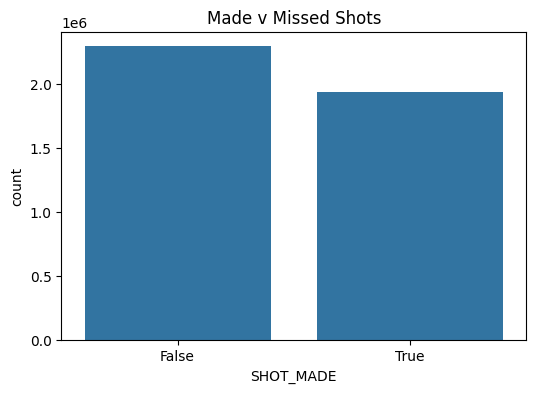

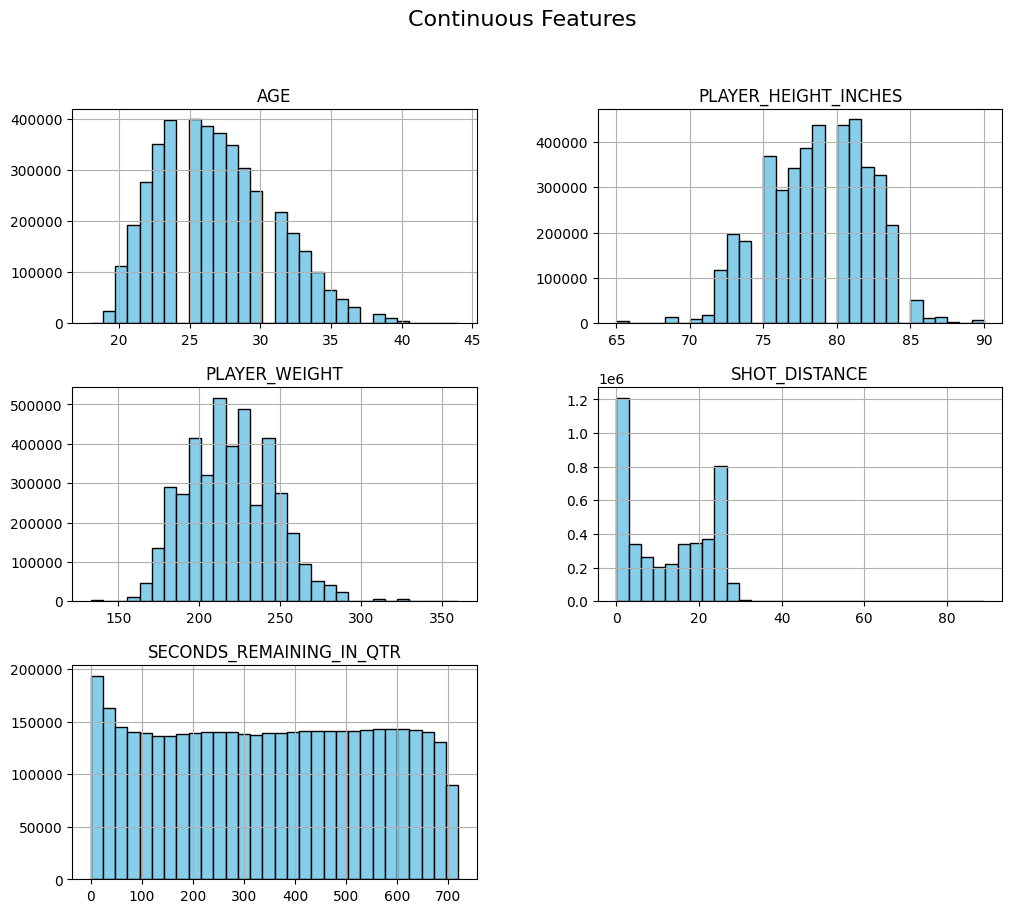

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='SHOT_MADE')
plt.title('Made v Missed Shots')
plt.show()

# Continuous Features Distributions
continuous_features = ['AGE', 'PLAYER_HEIGHT_INCHES', 'PLAYER_WEIGHT', 'SHOT_DISTANCE', 'SECONDS_REMAINING_IN_QTR']

df[continuous_features].hist(bins=30, figsize=(12, 10), color='skyblue', edgecolor='black')
plt.suptitle('Continuous Features', fontsize=16)
plt.show()

Prior to the multicolinearity check, it is necessary to convert the categorical features into numerical ones.

In [10]:
print(df.dtypes)

POSITION_GROUP               object
POSITION                     object
EVENT_TYPE                   object
SHOT_MADE                      bool
ACTION_TYPE                  object
SHOT_TYPE                    object
BASIC_ZONE                   object
ZONE_NAME                    object
ZONE_ABB                     object
ZONE_RANGE                   object
LOC_X                       float64
LOC_Y                       float64
SHOT_DISTANCE                 int64
QUARTER                       int64
AGE                         float64
PLAYER_HEIGHT_INCHES        float64
PLAYER_WEIGHT               float64
DRAFT_YEAR                   object
SEASON_1                      int64
SECONDS_REMAINING_IN_QTR      int64
dtype: object


As an effort to mitigate the amount of new columns that will arise due to encoding, removing the `ZONE` categories is acceptable since `LOC_X`, `LOC_Y`, and `SHOT_DISTANCE` are provided as features of their own. Similarly, certain actions that are exceptionally rare can be combined into one "other" category. More, `POSITION_GROUP` (Guard, Forward, Center) is a generalized version of `POSITION` (PG, SG, SF, PF, C), and hence can be dropped.

In [11]:
# Drop categorical text descriptions of the court before encoding
redundant_spatial_cols = ['ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE', 'BASIC_ZONE']
df = df.drop(columns=redundant_spatial_cols, errors='ignore')

# Frequency of ACTION_TYPE
action_counts = df['ACTION_TYPE'].value_counts(normalize=True)

# Actions that make up less than 1% of all shots
rare_actions = action_counts[action_counts < 0.01].index

# Replace with 'Other'
df['ACTION_TYPE'] = df['ACTION_TYPE'].replace(rare_actions, 'Other')

df = df.drop(columns=['POSITION_GROUP'], errors='ignore')

In [12]:
print("Dataset shape prior to encoding:", df.shape)
print()

categorical_cols = ['POSITION', 'EVENT_TYPE', 'ACTION_TYPE',
                    'SHOT_TYPE']

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# Convert target to integer
df_encoded['SHOT_MADE'] = df_encoded['SHOT_MADE'].astype(int)

print("Dataset shape after encoding:", df_encoded.shape)
print()
print(df_encoded.dtypes)

Dataset shape prior to encoding: (4231262, 15)

Dataset shape after encoding: (4231262, 46)

SHOT_MADE                                       int64
LOC_X                                         float64
LOC_Y                                         float64
SHOT_DISTANCE                                   int64
QUARTER                                         int64
AGE                                           float64
PLAYER_HEIGHT_INCHES                          float64
PLAYER_WEIGHT                                 float64
DRAFT_YEAR                                     object
SEASON_1                                        int64
SECONDS_REMAINING_IN_QTR                        int64
POSITION_C-PF                                   int64
POSITION_PF                                     int64
POSITION_PF-C                                   int64
POSITION_PF-SF                                  int64
POSITION_PG                                     int64
POSITION_PG-SF                             

`DRAFT_YEAR` remains as type `object`. This is due to various players having "Undrafted" as the assigned value. For practical purposes, this feature will be dropped.

The encoding has further revealed that `EVENT_TYPE` should be removed to prevent data leakage as it reveals whether or not the shot has been missed.

In [13]:
df_encoded = df_encoded.drop(columns=['DRAFT_YEAR'], errors='ignore')
df_encoded = df_encoded.drop(columns=['EVENT_TYPE_Missed Shot'], errors='ignore')

Due to the size of the dataset, memory usage will be immense if the variance inflation factor is calculated for each feature based on all data, so a random sample of 100,000 data points will suffice.

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

print("---Multicollinearity Check---")

# Separate features from the target
X = df_encoded.drop(columns=['SHOT_MADE'])

X = X.sample(n=100000, random_state=555)

# Drop any remaining NaNs to prevent math errors
X = X.dropna()

# Add a constant for VIF to be properly calculated
X_with_const = sm.add_constant(X)

# Calculate VIF for every feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                   for i in range(X_with_const.shape[1])]

vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

print("Top 15 Highest VIF Scores:")
print(vif_data.head(15).to_string(index=False))

---Multicollinearity Check---
Top 15 Highest VIF Scores:
                         Feature       VIF
           ACTION_TYPE_Jump Shot 29.615521
               ACTION_TYPE_Other 11.211829
          ACTION_TYPE_Layup Shot 10.420671
                   SHOT_DISTANCE  9.146345
                     POSITION_PG  7.638936
  ACTION_TYPE_Driving Layup Shot  7.247094
    ACTION_TYPE_Pullup Jump shot  6.876814
                     POSITION_SG  5.244391
            PLAYER_HEIGHT_INCHES  5.153262
                   PLAYER_WEIGHT  3.810359
 ACTION_TYPE_Step Back Jump shot  3.245305
        SHOT_TYPE_3PT Field Goal  3.225263
                     POSITION_SF  2.967213
ACTION_TYPE_Turnaround Jump Shot  2.731636
   ACTION_TYPE_Running Jump Shot  2.717079


Evidently, several `ACTION_TYPE` features have notably high VIF scores, which suggests that dropping all `ACTION_TYPE` features is likely preferable.

As suggested by the VIF analysis, we will drop the `ACTION_TYPE` columns to reduce multicollinearity and memory usage.

In [15]:
columns_to_drop = [col for col in df_encoded.columns if col.startswith('ACTION_TYPE_')]
df_encoded = df_encoded.drop(columns=columns_to_drop, errors='ignore')

print("Dataset shape after dropping ACTION_TYPE columns:", df_encoded.shape)

Dataset shape after dropping ACTION_TYPE columns: (4231262, 27)


In [16]:
from sklearn.model_selection import train_test_split

# Drop any NaNs
df_clean = df_encoded.dropna()
X = df_clean.drop(columns=['SHOT_MADE'])
y = df_clean['SHOT_MADE']

# Split into training (98%), validation (1%), and testing (1%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.02, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (4146527, 26)
Validation set shape: (42311, 26)
Test set shape: (42312, 26)


We have to examine the distribution of the target variable `SHOT_MADE` to understand if there's any class imbalance.

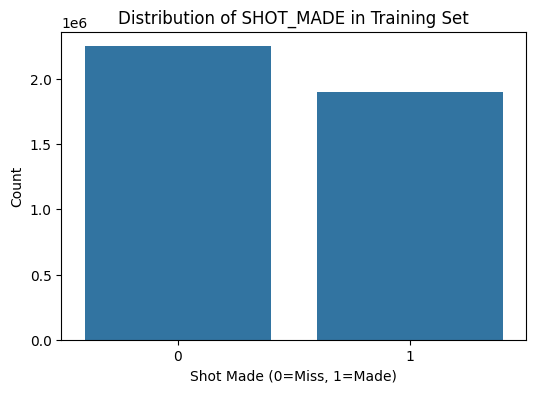

SHOT_MADE distribution in training set:
SHOT_MADE
0    0.542321
1    0.457679
Name: proportion, dtype: float64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class balance in the training set
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title('Distribution of SHOT_MADE in Training Set')
plt.xlabel('Shot Made (0=Miss, 1=Made)')
plt.ylabel('Count')
plt.show()

print("SHOT_MADE distribution in training set:")
print(y_train.value_counts(normalize=True))

The class distribution shows a slight imbalance, with `SHOT_MADE=0` (missed shots) being more prevalent than `SHOT_MADE=1` (made shots) which is common in basketball shots data.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=500, class_weight='balanced')
logistic_model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_val = logistic_model.predict(X_val)

# Evaluate the model
print("Accuracy:")
print(accuracy_score(y_val, y_pred_val))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_val))

Accuracy:
0.589988419087235

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.62      0.62     22946
           1       0.55      0.56      0.56     19365

    accuracy                           0.59     42311
   macro avg       0.59      0.59      0.59     42311
weighted avg       0.59      0.59      0.59     42311


Confusion Matrix:
[[14143  8803]
 [ 8545 10820]]


Train and Compare Ensemble's and simple MLP to evaluate against baseline

In [19]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import pandas as pd

# Use a subset for tuning to keep runtime practical since large dataset
tune_n = min(120000, len(X_train))
X_tune = X_train.sample(n=tune_n, random_state=42)
y_tune = y_train.loc[X_tune.index]

print(f"Tuning subset shape: {X_tune.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

searches = {}

# 1) Random Forest (ensemble)
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf_param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 12, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

searches["Random Forest"] = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=8,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 2) XGBoost (ensemble)
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1
)
xgb_param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 3.0]
}

searches["XGBoost"] = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=8,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)


# 3) Neural Network
nn_pipeline = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    (
        "mlp",
        MLPClassifier(
            random_state=42,
            max_iter=120,
            early_stopping=True,
            n_iter_no_change=5
        )
    )
])

nn_param_dist = {
    "mlp__hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32)],
    "mlp__alpha": [1e-4, 5e-4, 1e-3],
    "mlp__learning_rate_init": [5e-4, 1e-3],
    "mlp__batch_size": [256, 512]
}

searches["Neural Network (MLP)"] = RandomizedSearchCV(
    estimator=nn_pipeline,
    param_distributions=nn_param_dist,
    n_iter=8,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

best_models = {}
results = []

# Train and tune each model
for name, search in searches.items():
    print(f"\nTuning {name}:")
    search.fit(X_tune, y_tune)
    best_models[name] = search.best_estimator_

    print(f"Best CV F1 ({name}): {search.best_score_:.4f}")
    print(f"Best params ({name}): {search.best_params_}")

    y_val_pred = search.best_estimator_.predict(X_val)
    y_test_pred = search.best_estimator_.predict(X_test)

    results.append({
        "Model": name,
        "Val_Accuracy": accuracy_score(y_val, y_val_pred),
        "Val_Precision": precision_score(y_val, y_val_pred, zero_division=0),
        "Val_Recall": recall_score(y_val, y_val_pred, zero_division=0),
        "Val_F1": f1_score(y_val, y_val_pred, zero_division=0),
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Test_Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Test_Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "Test_F1": f1_score(y_test, y_test_pred, zero_division=0)
    })

comparison_df = pd.DataFrame(results).sort_values(by="Val_F1", ascending=False)

print("\nModel Comparison (sorted by Validation F1):")
print(comparison_df.to_string(index=False))

# Final selection by validation F1
best_model_name = comparison_df.iloc[0]["Model"]
final_model = best_models[best_model_name]

print(f"\nSelected best model: {best_model_name}")

# Final evaluation details on the test set for selected model
y_test_final = final_model.predict(X_test)

print("\nFinal Model Test Classification Report:")
print(classification_report(y_test, y_test_final, zero_division=0))

print("Final Model Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_final))

Tuning subset shape: (120000, 26)
Validation set shape: (42311, 26)
Test set shape: (42312, 26)

Tuning Random Forest:
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV F1 (Random Forest): 0.5043
Best params (Random Forest): {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}

Tuning XGBoost:
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV F1 (XGBoost): 0.5006
Best params (XGBoost): {'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Tuning Neural Network (MLP):
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV F1 (Neural Network (MLP)): 0.5461
Best params (Neural Network (MLP)): {'mlp__learning_rate_init': 0.0005, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__batch_size': 512, 'mlp__alpha': 0.001}

Model Comparison (sorted by Validation F1):
               Model  Val_Accuracy  Val_Precision  Val_Recall  

All models perform better than the baseline logistic regression model. RandomForest performs slightly better than XGBoost and the MLP, having the highest F1-score. Improvement over baseline is minimal, however the models do perform better than a random classifier.

Next, we try a pytorch neural network with hyperparameter tuning. We apply the same standard scaler as for the MLP and we tune the model using optuna. We then train best model on the full training set and then evaluate on test set to see if it will perform better than the sklearn models on the held out test set.

In [20]:
# Install Optuna if not already installed
%pip install optuna

In [21]:
# PyTorch neural network imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import optuna
from optuna.samplers import TPESampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix
import warnings, time
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on train
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Convert to tensors
def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32), torch.tensor(y.values, dtype=torch.float32))

X_tr_t, y_tr_t = to_tensor(X_train_sc, y_train)
X_va_t, y_va_t = to_tensor(X_val_sc,   y_val)
X_te_t, y_te_t = to_tensor(X_test_sc,  y_test)

num_features = X_tr_t.shape[1]
print(f"Input features: {num_features}")
print(f"Train / Val / Test tensors ready.")


Using device: cuda
Input features: 26
Train / Val / Test tensors ready.


In [22]:
# Feed Forward Neural Net Classifier
class ShotNet(nn.Module):
    """
    Fully-connected network for binary shot-prediction.
    n_features: int – number of input features
    hidden_sizes: list – neuron counts for each hidden layer
    dropout_rate: float – dropout probability applied after every hidden layer
    use_batchnorm: bool – whether to add BatchNorm1d after each linear layer
    """
    def __init__(self, n_features: int, hidden_sizes: list,
                 dropout_rate: float = 0.3, use_batchnorm: bool = True):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))   # binary logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)          # shape (B,)


def train_epoch(model, loader, optimiser, criterion):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimiser.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, X_t, y_t, threshold=0.5):
    model.eval()
    logits = model(X_t.to(device)).cpu()
    probs  = torch.sigmoid(logits).numpy()
    preds  = (probs >= threshold).astype(int)
    labels = y_t.numpy().astype(int)
    return {
        "accuracy" : accuracy_score(labels, preds),
        "precision" : precision_score(labels, preds, zero_division=0),
        "recall" : recall_score(labels, preds, zero_division=0),
        "f1" : f1_score(labels, preds, zero_division=0),
        "preds" : preds,
        "labels" : labels,
    }




**Hyperparameter search with Optuna**

Optuna's TPE sampler explores the search space.
Each **trial** trains for up to 30 epochs with early stopping (patience = 5).
The objective is **validation F1** – consistent with what we used for sklearn.

Search space:

| Parameter | Range |
|---|---|
| Number of hidden layers | 1 – 3 |
| Units per layer | 64, 128, 256, 512 |
| Dropout rate | 0.1 – 0.5 |
| Batch normalisation | True / False |
| Learning rate | 1e-4 – 1e-2 (log-uniform) |
| Weight decay | 1e-5 – 1e-2 (log-uniform) |
| Batch size | 256, 512, 1024 |
| Optimiser | Adam / AdamW |


In [23]:
# Use a fixed subset for tuning
TUNE_SIZE  = min(80_000, len(X_train_sc))
idx_tune   = np.random.default_rng(45).choice(len(X_train_sc), TUNE_SIZE, replace=False)

X_tn_t = X_tr_t[idx_tune]
y_tn_t = y_tr_t[idx_tune]

# Positive-class weight for BCEWithLogitsLoss (handle class imbalance)
pos_weight_val = (y_tn_t == 0).sum() / (y_tn_t == 1).sum()
pos_weight_tensor = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)


def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    unit_choices = [64, 128, 256, 512]
    hidden_sizes = [trial.suggest_categorical(f"units_l{i}", unit_choices) for i in range(n_layers)]
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.5)
    use_bn = trial.suggest_categorical("batchnorm", [True, False])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("wd", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [256, 512, 1024])
    opt_name = trial.suggest_categorical("optimiser", ["Adam", "AdamW"])

    # Build the model
    model = ShotNet(num_features, hidden_sizes, dropout_rate, use_bn).to(device)
    OptimizerClass = optim.Adam if opt_name == "Adam" else optim.AdamW
    optimizer = OptimizerClass(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    loader = DataLoader(
        TensorDataset(X_tn_t, y_tn_t),
        batch_size=batch_size, shuffle=True
    )

    # Train with early stopping
    best_val_f1, patience_cnt, MAX_EPOCHS, PATIENCE = 0, 0, 30, 5
    for epoch in range(MAX_EPOCHS):
        train_epoch(model, loader, optimizer, criterion)
        metrics = evaluate(model, X_va_t, y_va_t)
        val_f1  = metrics["f1"]

        trial.report(val_f1, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                break

    return best_val_f1


# Run the optuna trials
N_TRIALS = 30
print(f"Starting Optuna study – {N_TRIALS} trials")
t0 = time.time()

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=N_TRIALS)

elapsed = time.time() - t0
print(f"\nSearch finished in {elapsed/60:.1f} min")
print(f"Best validation F1 : {study.best_value:.4f}")
print(f"Best hyperparameters: {study.best_params}")


[I 2026-04-09 15:26:49,483] A new study created in memory with name: no-name-a963164d-0e9f-4af4-a918-4841276d2c94


Starting Optuna study – 30 trials

Search finished in 1.1 min
Best validation F1 : 0.5810
Best hyperparameters: {'n_layers': 3, 'units_l0': 512, 'units_l1': 64, 'units_l2': 128, 'dropout': 0.22393303373337886, 'batchnorm': False, 'lr': 0.00013411178839591365, 'wd': 0.00024406817347710744, 'batch_size': 1024, 'optimiser': 'AdamW'}


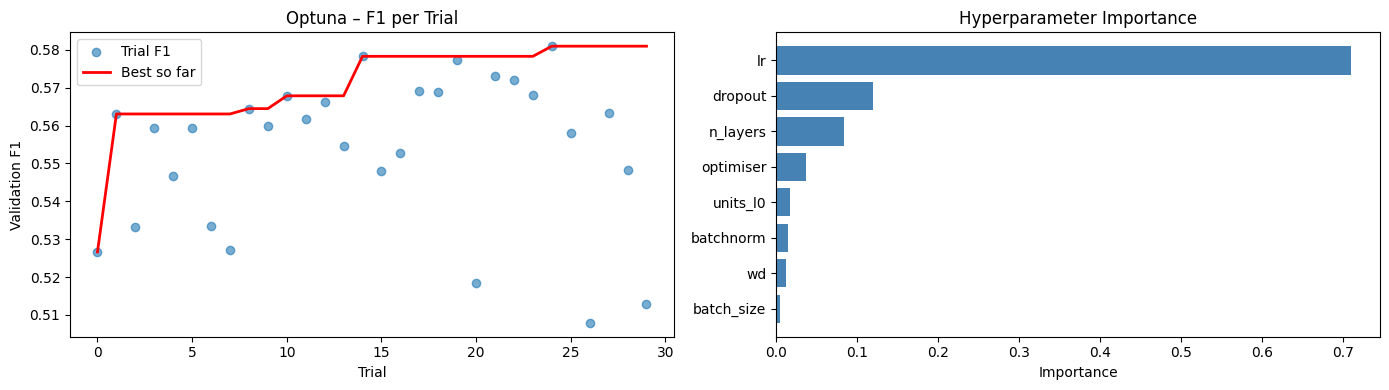

In [24]:
# Visualize the Optuna trials
import matplotlib.pyplot as plt

trial_nums = [t.number for t in study.trials if t.value is not None]
trial_vals = [t.value  for t in study.trials if t.value is not None]
running_best = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(trial_nums, trial_vals, alpha=0.6, label="Trial F1")
axes[0].plot(trial_nums, running_best, color="red", lw=2, label="Best so far")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Validation F1")
axes[0].set_title("Optuna – F1 per Trial"); axes[0].legend()

# Parameter importance (top 8)
try:
    importances = optuna.importance.get_param_importances(study)
    params  = list(importances.keys())[:8]
    imp_vals = [importances[p] for p in params]
    axes[1].barh(params[::-1], imp_vals[::-1], color="steelblue")
    axes[1].set_xlabel("Importance"); axes[1].set_title("Hyperparameter Importance")
except Exception:
    axes[1].text(0.5, 0.5, "Importance requires >1 completed trial", ha="center", va="center")

plt.tight_layout()
plt.show()

In [25]:
# Reconstruct best model & train on all training data
bp = study.best_params
n_layers = bp["n_layers"]
hidden_sizes = [bp[f"units_l{i}"] for i in range(n_layers)]
dropout_rate = bp["dropout"]
use_bn = bp["batchnorm"]
lr = bp["lr"]
wd = bp["wd"]
batch_size = bp["batch_size"]
opt_name = bp["optimiser"]

best_pytorch = ShotNet(num_features, hidden_sizes, dropout_rate, use_bn).to(device)
OptimizerClass = optim.Adam if opt_name == "Adam" else optim.AdamW
optimizer   = OptimizerClass(best_pytorch.parameters(), lr=lr, weight_decay=wd)

# Recompute pos_weight on the full training set
pos_weight_full = (y_tr_t == 0).sum() / (y_tr_t == 1).sum()
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_full], dtype=torch.float32).to(device)
)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=batch_size, shuffle=True
)

MAX_EPOCHS, PATIENCE = 60, 10
best_val_f1, patience_cnt = 0, 0
history = {"train_loss": [], "val_f1": []}

print("Training best PyTorch model on full training set")
for epoch in range(1, MAX_EPOCHS + 1):
    loss = train_epoch(best_pytorch, train_loader, optimizer, criterion)
    val_m = evaluate(best_pytorch, X_va_t, y_va_t)
    history["train_loss"].append(loss)
    history["val_f1"].append(val_m["f1"])

    if val_m["f1"] > best_val_f1:
        best_val_f1 = val_m["f1"]
        patience_cnt = 0
        # Save weights of best checkpoint
        best_state = {k: v.clone() for k, v in best_pytorch.state_dict().items()}
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break

    print(f"  Epoch {epoch:>3} | loss={loss:.4f} | val_f1={val_m['f1']:.4f}")

# Restore best weights
best_pytorch.load_state_dict(best_state)
print(f"\nBest validation F1 during final training: {best_val_f1:.4f}")


Training best PyTorch model on full training set
  Epoch   1 | loss=0.7226 | val_f1=0.5029
  Epoch   2 | loss=0.7193 | val_f1=0.5000
  Epoch   3 | loss=0.7183 | val_f1=0.4997
  Epoch   4 | loss=0.7177 | val_f1=0.4987
  Epoch   5 | loss=0.7173 | val_f1=0.5025
  Epoch   6 | loss=0.7171 | val_f1=0.5007
  Epoch   7 | loss=0.7168 | val_f1=0.5014
  Epoch   8 | loss=0.7166 | val_f1=0.5008
  Epoch   9 | loss=0.7165 | val_f1=0.5017
  Epoch  10 | loss=0.7164 | val_f1=0.5013
  Epoch  11 | loss=0.7162 | val_f1=0.5029
  Epoch  12 | loss=0.7161 | val_f1=0.5049
  Epoch  13 | loss=0.7160 | val_f1=0.5041
  Epoch  14 | loss=0.7159 | val_f1=0.5011
  Epoch  15 | loss=0.7159 | val_f1=0.5011
  Epoch  16 | loss=0.7158 | val_f1=0.5036
  Epoch  17 | loss=0.7157 | val_f1=0.5041
  Epoch  18 | loss=0.7156 | val_f1=0.5017
  Epoch  19 | loss=0.7155 | val_f1=0.5005
  Epoch  20 | loss=0.7155 | val_f1=0.5023
  Epoch  21 | loss=0.7154 | val_f1=0.5068
  Epoch  22 | loss=0.7154 | val_f1=0.5026
  Epoch  23 | loss=0.7153 |

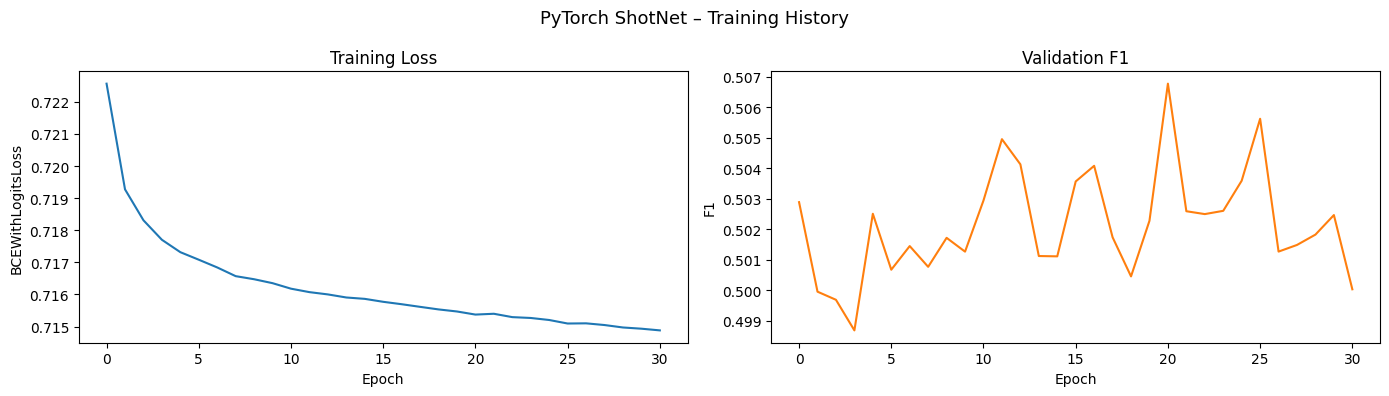

In [26]:
# Training Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["train_loss"], color="tab:blue")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCEWithLogitsLoss")
axes[0].set_title("Training Loss")

axes[1].plot(history["val_f1"], color="tab:orange")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1")
axes[1].set_title("Validation F1")

plt.suptitle("PyTorch ShotNet – Training History", fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
# Evaluate PyTorch model on test set
pt_test_metrics = evaluate(best_pytorch, X_te_t, y_te_t)

pt_row = {
    "Model" : "PyTorch ShotNet (Optuna)",
    "Val_Accuracy" : evaluate(best_pytorch, X_va_t, y_va_t)["accuracy"],
    "Val_Precision" : evaluate(best_pytorch, X_va_t, y_va_t)["precision"],
    "Val_Recall" : evaluate(best_pytorch, X_va_t, y_va_t)["recall"],
    "Val_F1" : evaluate(best_pytorch, X_va_t, y_va_t)["f1"],
    "Test_Accuracy" : pt_test_metrics["accuracy"],
    "Test_Precision" : pt_test_metrics["precision"],
    "Test_Recall" : pt_test_metrics["recall"],
    "Test_F1" : pt_test_metrics["f1"],
}

# Append to the existing comparison dataframe
full_comparison = pd.concat(
    [comparison_df, pd.DataFrame([pt_row])],
    ignore_index=True
).sort_values("Val_F1", ascending=False)

print("\nFull Model Comparison (sorted by Val F1):")
print(full_comparison.to_string(index=False))



Full Model Comparison (sorted by Val F1):
                   Model  Val_Accuracy  Val_Precision  Val_Recall   Val_F1  Test_Accuracy  Test_Precision  Test_Recall  Test_F1
           Random Forest      0.612512       0.604977    0.441931 0.510758       0.608622        0.598442     0.440279 0.507319
    Neural Network (MLP)      0.614474       0.609986    0.437180 0.509325       0.613774        0.607511     0.441053 0.511070
PyTorch ShotNet (Optuna)      0.621871       0.628748    0.424426 0.506767       0.621597        0.626949     0.427679 0.508488
                 XGBoost      0.609321       0.603869    0.425562 0.499273       0.605856        0.597194     0.426439 0.497575


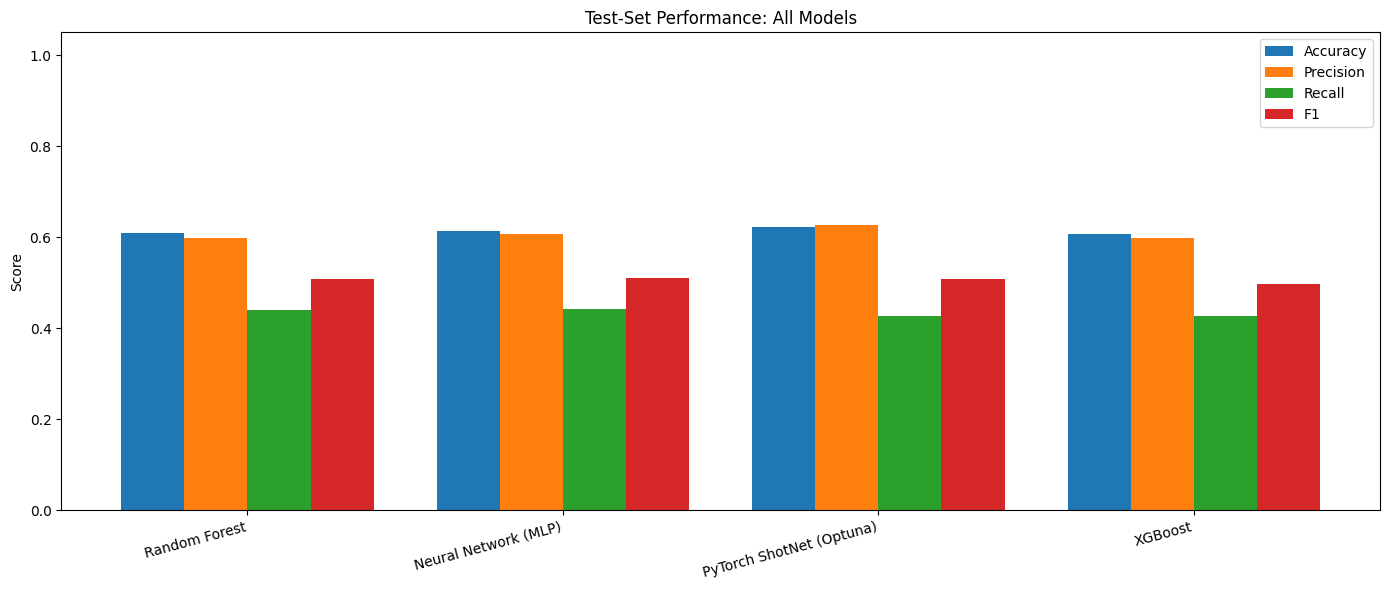


PyTorch ShotNet – Test Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.79      0.69     22947
           1       0.63      0.43      0.51     19365

    accuracy                           0.62     42312
   macro avg       0.62      0.61      0.60     42312
weighted avg       0.62      0.62      0.61     42312

PyTorch ShotNet – Test Confusion Matrix:
[[18019  4928]
 [11083  8282]]


In [28]:
# Bar Chart Comparison
metrics_plot = ["Test_Accuracy", "Test_Precision", "Test_Recall", "Test_F1"]
labels = full_comparison["Model"].tolist()
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics_plot):
    ax.bar(x + i * width, full_comparison[metric], width, label=metric.replace("Test_", ""))

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Test-Set Performance: All Models")
ax.legend()
plt.tight_layout()
plt.show()

# Print PyTorch detailed report
print("\nPyTorch ShotNet – Test Classification Report:")
print(classification_report(pt_test_metrics["labels"], pt_test_metrics["preds"], zero_division=0))

print("PyTorch ShotNet – Test Confusion Matrix:")
print(confusion_matrix(pt_test_metrics["labels"], pt_test_metrics["preds"]))


**Temporal Analysis**

We want to check if training on newer vs older data changes prediction quality

NBA shooting has evolved dramatically: the three-point revolution, pace-and-space offences, and analytics-driven shot selection have all reshaped which shots are attempted and which are made.

1. **Recency bias** – does a model trained on recent seasons generalise better to the test set than one trained on older seasons?
2. **Temporal generalisation** – is there a growing gap between models trained on early-era data and the present-day test distribution?

**Methodology**
* The full dataset is sorted by `SEASON_1`.
* We define **N temporal windows**, each containing roughly equal amounts of data, spanning the full 2004–2024 range.
* For each window we train a **LightGBM** classifier (fast, robust) on that window's data alone and evaluate on the *common held-out test set* (same random split used throughout).
* We repeat with an **expanding window** (cumulative training) to show how adding more history affects performance.
* Finally we compare: *Train on newest 30%* vs *Train on oldest 30%* – a direct head-to-head.

In [29]:
# Temporal Analysis Setup
import lightgbm as lgb
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# Re-attach the SEASON_1 column to the cleaned encoded frame so we can split by year
# df_clean was defined before the train/test split cell
df_temporal = df_clean.copy()   # has SEASON_1 still present (it's numeric after concat)

seasons_sorted = sorted(df_temporal["SEASON_1"].unique())
print(f"Seasons available: {seasons_sorted[0]} --> {seasons_sorted[-1]}  ({len(seasons_sorted)} seasons)")
print(f"Test set size: {len(X_test):,} rows")


Seasons available: 2004 --> 2024  (21 seasons)
Test set size: 42,312 rows


In [30]:
# Helper function to train LightGBM on a subset of data and then evaluate on test
def train_eval_lgbm(X_tr, y_tr, X_te=X_test, y_te=y_test, seed=42):
    """Train a tuned LightGBM on (X_tr, y_tr) and return test-set metrics."""
    scale_pos = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    clf = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
    )
    clf.fit(X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(30, verbose=False),
                       lgb.log_evaluation(period=-1)])
    preds = clf.predict(X_te)
    proba = clf.predict_proba(X_te)[:, 1]
    return {
        "accuracy" : accuracy_score(y_te, preds),
        "f1"       : f1_score(y_te, preds, zero_division=0),
        "roc_auc"  : roc_auc_score(y_te, proba),
        "n_train"  : len(X_tr),
    }


**Experiment 1** - 3 season rolling window

Each model trained on 3 season rolling window and tested on held out set.

In [31]:
# Rolling 3 season window experiment
WINDOW = 3
rolling_results = []

feature_cols = [c for c in df_temporal.columns if c not in ["SHOT_MADE", "SEASON_1"]]

for i in range(len(seasons_sorted) - WINDOW + 1):
    window_seasons = seasons_sorted[i : i + WINDOW]
    mask = df_temporal["SEASON_1"].isin(window_seasons)
    subset = df_temporal[mask].dropna()

    X_w = subset[feature_cols]
    y_w = subset["SHOT_MADE"].astype(int)

    # Align columns with X_test (in case some OHE cols are absent in the window)
    X_w = X_w.reindex(columns=X_test.columns, fill_value=0)

    metrics = train_eval_lgbm(X_w, y_w)
    metrics["window_start"] = window_seasons[0]
    metrics["window_end"]   = window_seasons[-1]
    metrics["label"]        = f"{window_seasons[0]}–{window_seasons[-1]}"
    rolling_results.append(metrics)
    print(f"  {metrics['label']:12s}  n={metrics['n_train']:>8,}  "
          f"F1={metrics['f1']:.4f}  AUC={metrics['roc_auc']:.4f}")

rolling_df = pd.DataFrame(rolling_results)


  2004–2006     n= 581,743  F1=0.4973  AUC=0.6336
  2005–2007     n= 588,012  F1=0.5084  AUC=0.6366
  2006–2008     n= 590,887  F1=0.5101  AUC=0.6359
  2007–2009     n= 595,603  F1=0.5117  AUC=0.6331
  2008–2010     n= 600,497  F1=0.5129  AUC=0.6337
  2009–2011     n= 599,757  F1=0.5050  AUC=0.6332
  2010–2012     n= 561,932  F1=0.5036  AUC=0.6330
  2011–2013     n= 562,545  F1=0.4931  AUC=0.6280
  2012–2014     n= 566,910  F1=0.4892  AUC=0.6292
  2013–2015     n= 611,143  F1=0.4843  AUC=0.6275
  2014–2016     n= 617,457  F1=0.4874  AUC=0.6294
  2015–2017     n= 623,260  F1=0.4846  AUC=0.6290
  2016–2018     n= 629,529  F1=0.4926  AUC=0.6311
  2017–2019     n= 641,094  F1=0.5021  AUC=0.6312
  2018–2020     n= 619,281  F1=0.4918  AUC=0.6305
  2019–2021     n= 598,557  F1=0.4931  AUC=0.6317
  2020–2022     n= 595,821  F1=0.4915  AUC=0.6296
  2021–2023     n= 624,925  F1=0.5089  AUC=0.6304
  2022–2024     n= 652,643  F1=0.5140  AUC=0.6321


**Experiment 2** Part 1 – Expanding (Cumulative) Window

Start from the oldest season and progressively add more seasons — does more data always help?

In [32]:
# Expanding Window
expanding_results = []

for end_idx in range(1, len(seasons_sorted) + 1):
    window_seasons = seasons_sorted[:end_idx]
    mask = df_temporal["SEASON_1"].isin(window_seasons)
    subset = df_temporal[mask].dropna()

    X_w = subset[feature_cols].reindex(columns=X_test.columns, fill_value=0)
    y_w = subset["SHOT_MADE"].astype(int)

    metrics = train_eval_lgbm(X_w, y_w)
    metrics["seasons_used"] = end_idx
    metrics["last_season"]  = window_seasons[-1]
    expanding_results.append(metrics)
    print(f"  Up to {window_seasons[-1]}  ({end_idx} seasons)  "
          f"n={metrics['n_train']:>8,}  F1={metrics['f1']:.4f}  AUC={metrics['roc_auc']:.4f}")

expanding_df = pd.DataFrame(expanding_results)



  Up to 2004  (1 seasons)  n= 189,803  F1=0.4885  AUC=0.6307
  Up to 2005  (2 seasons)  n= 387,429  F1=0.4912  AUC=0.6326
  Up to 2006  (3 seasons)  n= 581,743  F1=0.4973  AUC=0.6336
  Up to 2007  (4 seasons)  n= 777,815  F1=0.5043  AUC=0.6360
  Up to 2008  (5 seasons)  n= 978,316  F1=0.5064  AUC=0.6378
  Up to 2009  (6 seasons)  n=1,177,346  F1=0.5083  AUC=0.6377
  Up to 2010  (7 seasons)  n=1,378,312  F1=0.5092  AUC=0.6381
  Up to 2011  (8 seasons)  n=1,578,073  F1=0.5077  AUC=0.6378
  Up to 2012  (9 seasons)  n=1,739,278  F1=0.5063  AUC=0.6377
  Up to 2013  (10 seasons)  n=1,940,857  F1=0.5039  AUC=0.6381
  Up to 2014  (11 seasons)  n=2,144,983  F1=0.5025  AUC=0.6381
  Up to 2015  (12 seasons)  n=2,350,421  F1=0.5013  AUC=0.6386
  Up to 2016  (13 seasons)  n=2,558,314  F1=0.5000  AUC=0.6390
  Up to 2017  (14 seasons)  n=2,768,243  F1=0.5000  AUC=0.6389
  Up to 2018  (15 seasons)  n=2,979,950  F1=0.5014  AUC=0.6391
  Up to 2019  (16 seasons)  n=3,199,408  F1=0.5021  AUC=0.6392
  Up t

**Experiment 2** Part 2 – Expanding (Cumulative) Window

Start from the most recent season and progressively add more seasons — does more data always help?

In [33]:
expanding_results_backward = []
seasons_desc = list(reversed(seasons_sorted))
for end_idx in range(1, len(seasons_desc) + 1):
    window_seasons = seasons_desc[:end_idx]  # take most recent + expand backward
    mask = df_temporal["SEASON_1"].isin(window_seasons)
    subset = df_temporal[mask].dropna()

    X_w = subset[feature_cols].reindex(columns=X_test.columns, fill_value=0)
    y_w = subset["SHOT_MADE"].astype(int)

    metrics = train_eval_lgbm(X_w, y_w)
    metrics["seasons_used"] = end_idx
    metrics["first_season"] = window_seasons[-1]   # oldest in current window
    metrics["last_season"]  = window_seasons[0]    # most recent
    expanding_results_backward.append(metrics)

    print(f"  From {window_seasons[-1]} → {window_seasons[0]} "
          f"({end_idx} seasons)  n={metrics['n_train']:>8,}  "
          f"F1={metrics['f1']:.4f}  AUC={metrics['roc_auc']:.4f}")

expanding_df_backwards = pd.DataFrame(expanding_results_backward)

  From 2024 → 2024 (1 seasons)  n= 218,701  F1=0.5221  AUC=0.6315
  From 2023 → 2024 (2 seasons)  n= 435,921  F1=0.5228  AUC=0.6318
  From 2022 → 2024 (3 seasons)  n= 652,643  F1=0.5140  AUC=0.6321
  From 2021 → 2024 (4 seasons)  n= 843,626  F1=0.5092  AUC=0.6315
  From 2020 → 2024 (5 seasons)  n=1,031,742  F1=0.5080  AUC=0.6303
  From 2019 → 2024 (6 seasons)  n=1,251,200  F1=0.5055  AUC=0.6319
  From 2018 → 2024 (7 seasons)  n=1,462,907  F1=0.5041  AUC=0.6322
  From 2017 → 2024 (8 seasons)  n=1,672,836  F1=0.5027  AUC=0.6331
  From 2016 → 2024 (9 seasons)  n=1,880,729  F1=0.5017  AUC=0.6332
  From 2015 → 2024 (10 seasons)  n=2,086,167  F1=0.5048  AUC=0.6380
  From 2014 → 2024 (11 seasons)  n=2,290,293  F1=0.5043  AUC=0.6384
  From 2013 → 2024 (12 seasons)  n=2,491,872  F1=0.5039  AUC=0.6387
  From 2012 → 2024 (13 seasons)  n=2,653,077  F1=0.5030  AUC=0.6384
  From 2011 → 2024 (14 seasons)  n=2,852,838  F1=0.5036  AUC=0.6386
  From 2010 → 2024 (15 seasons)  n=3,053,804  F1=0.5031  AUC=

**Experiment 3** – Oldest 30% vs Newest 30% (Head-to-Head)

Direct comparison: does recency of training data matter?

In [34]:
# Oldest 30% vs Newest 30%
n_seasons = len(seasons_sorted)
cutoff     = max(1, round(n_seasons * 0.30))

oldest_seasons = seasons_sorted[:cutoff]
newest_seasons = seasons_sorted[-cutoff:]

def subset_for(season_list):
    mask = df_temporal["SEASON_1"].isin(season_list)
    sub  = df_temporal[mask].dropna()
    X_   = sub[feature_cols].reindex(columns=X_test.columns, fill_value=0)
    y_   = sub["SHOT_MADE"].astype(int)
    return X_, y_

X_old, y_old = subset_for(oldest_seasons)
X_new, y_new = subset_for(newest_seasons)

print(f"Oldest seasons : {oldest_seasons[0]}–{oldest_seasons[-1]}  n={len(X_old):,}")
print(f"Newest seasons : {newest_seasons[0]}–{newest_seasons[-1]}  n={len(X_new):,}")

old_metrics = train_eval_lgbm(X_old, y_old)
new_metrics = train_eval_lgbm(X_new, y_new)

head2head = pd.DataFrame([
    {"Split": f"Oldest {cutoff} seasons ({oldest_seasons[0]}–{oldest_seasons[-1]})",
     **{k: v for k, v in old_metrics.items() if k != "n_train"},
     "n_train": len(X_old)},
    {"Split": f"Newest {cutoff} seasons ({newest_seasons[0]}–{newest_seasons[-1]})",
     **{k: v for k, v in new_metrics.items() if k != "n_train"},
     "n_train": len(X_new)},
])

print("\nHead-to-Head Results")
print(head2head.to_string(index=False))

Oldest seasons : 2004–2009  n=1,177,346
Newest seasons : 2019–2024  n=1,251,200

Head-to-Head Results
                       Split  accuracy       f1  roc_auc  n_train
Oldest 6 seasons (2004–2009)  0.622306 0.508292 0.637663  1177346
Newest 6 seasons (2019–2024)  0.622495 0.505526 0.631940  1251200


Visualizations for the temporal results

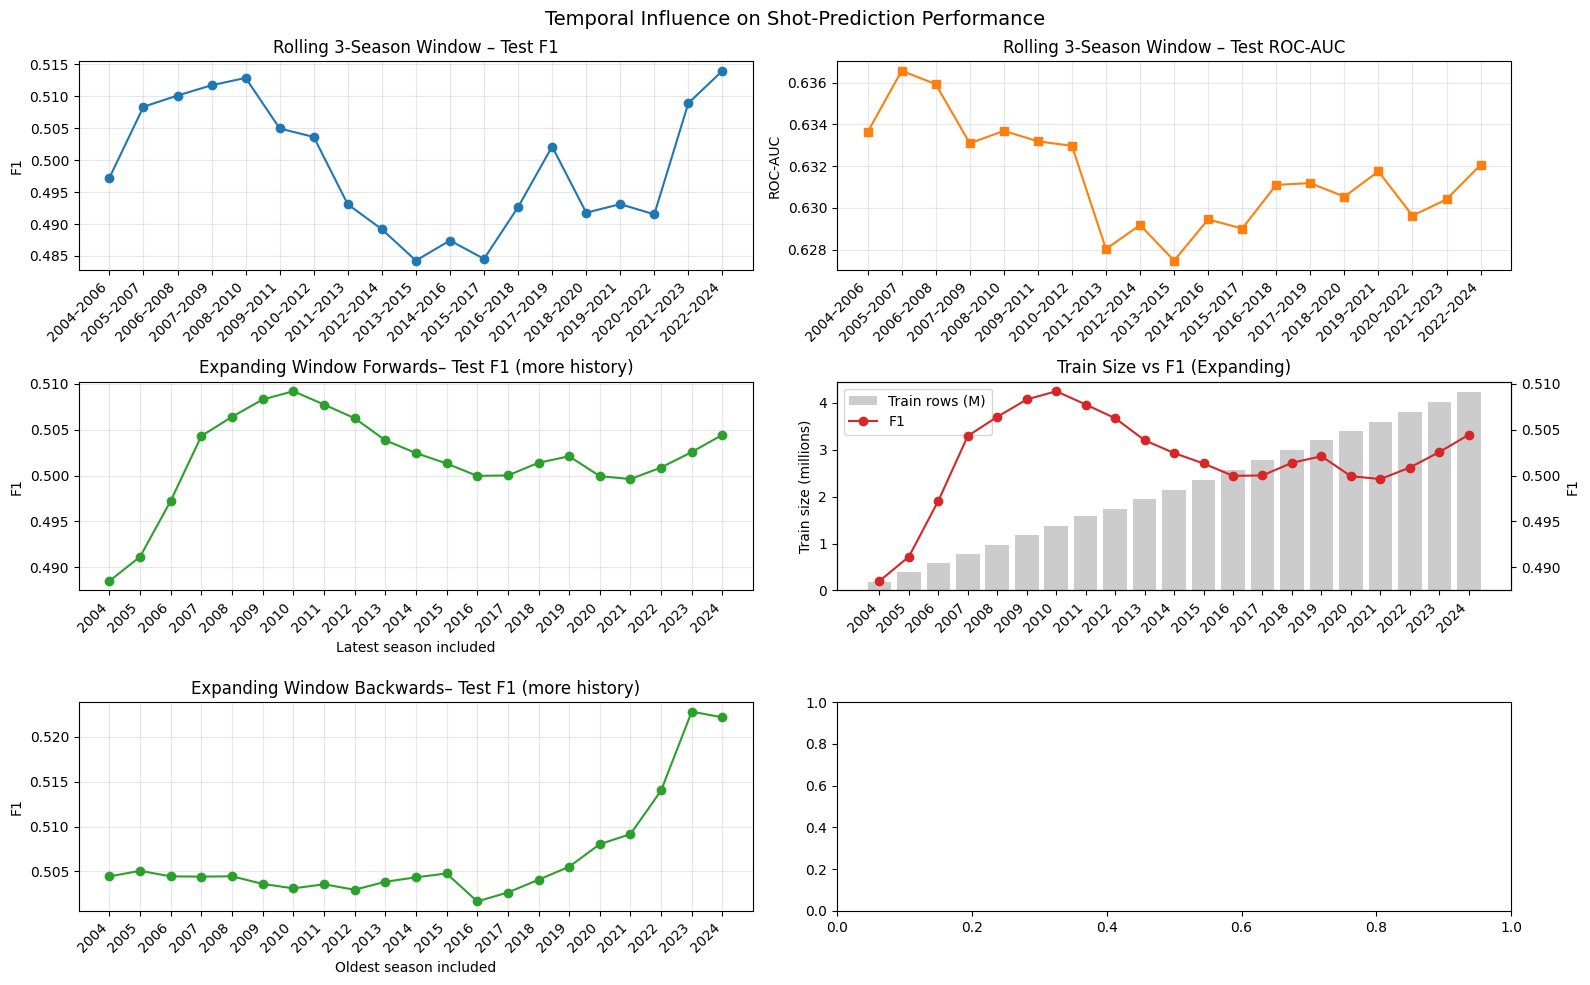

In [35]:
import matplotlib.pyplot as plt

# Temporal visualisations
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

# 1) Rolling F1
ax = axes[0, 0]
ax.plot(rolling_df["label"], rolling_df["f1"], marker="o", color="tab:blue")
ax.set_xticklabels(rolling_df["label"], rotation=45, ha="right")
ax.set_title("Rolling 3-Season Window – Test F1")
ax.set_ylabel("F1"); ax.grid(alpha=0.3)

# 2) Rolling AUC
ax = axes[0, 1]
ax.plot(rolling_df["label"], rolling_df["roc_auc"], marker="s", color="tab:orange")
ax.set_xticklabels(rolling_df["label"], rotation=45, ha="right")
ax.set_title("Rolling 3-Season Window – Test ROC-AUC")
ax.set_ylabel("ROC-AUC"); ax.grid(alpha=0.3)

# 3.1) Expanding F1
ax = axes[1, 0]
ax.plot(expanding_df["last_season"], expanding_df["f1"], marker="o", color="tab:green")
# Set x-ticks and labels explicitly for better alignment
ax.set_xticks(expanding_df["last_season"])
ax.set_xticklabels(expanding_df["last_season"].astype(str), rotation=45, ha="right")
ax.set_title("Expanding Window Forwards– Test F1 (more history)")
ax.set_xlabel("Latest season included"); ax.set_ylabel("F1"); ax.grid(alpha=0.3)

# 3.2) Expanding F1
ax = axes[2, 0]
ax.plot(expanding_df_backwards["first_season"], expanding_df_backwards["f1"], marker="o", color="tab:green")
# Set x-ticks and labels explicitly for better alignment
ax.set_xticks(expanding_df_backwards["first_season"])
ax.set_xticklabels(expanding_df_backwards["first_season"].astype(str), rotation=45, ha="right")
ax.set_title("Expanding Window Backwards– Test F1 (more history)")
ax.set_xlabel("Oldest season included"); ax.set_ylabel("F1"); ax.grid(alpha=0.3)

# 4) Expanding training set size vs F1
ax = axes[1, 1]
ax2 = ax.twinx()
ax.bar(expanding_df["last_season"], expanding_df["n_train"] / 1e6,
       alpha=0.4, color="gray", label="Train rows (M)")
ax2.plot(expanding_df["last_season"], expanding_df["f1"],
         color="tab:red", marker="o", label="F1")
# Set x-ticks and labels explicitly for better alignment
ax.set_xticks(expanding_df["last_season"])
ax.set_xticklabels(expanding_df["last_season"].astype(str), rotation=45, ha="right")
ax.set_ylabel("Train size (millions)"); ax2.set_ylabel("F1")
ax.set_title("Train Size vs F1 (Expanding)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.suptitle("Temporal Influence on Shot-Prediction Performance", fontsize=14)
plt.tight_layout()
plt.show()

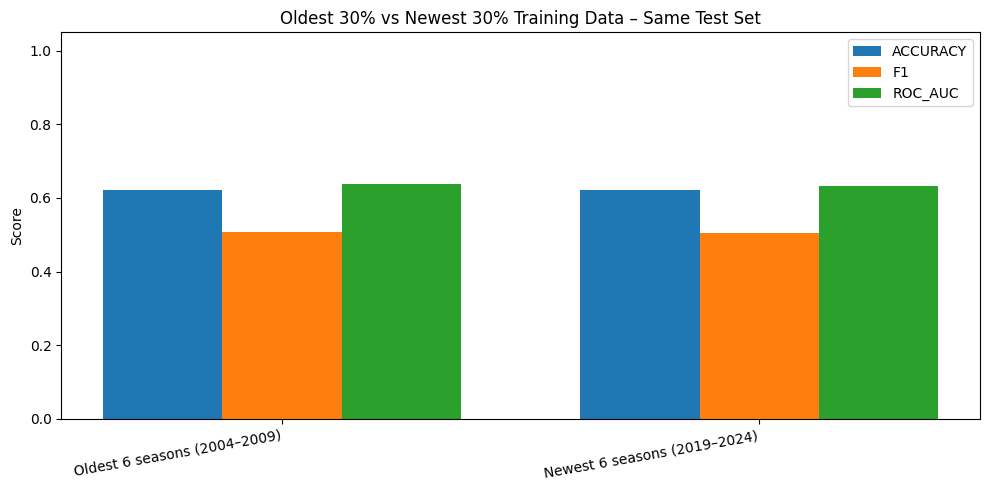

In [36]:
# Head-to-head bar chart
h2h_metrics = ["accuracy", "f1", "roc_auc"]
labels_h2h  = head2head["Split"].tolist()
x_h2h = np.arange(len(labels_h2h))
width_h2h = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, metric in enumerate(h2h_metrics):
    ax.bar(x_h2h + i * width_h2h, head2head[metric], width_h2h,
           label=metric.upper())

ax.set_xticks(x_h2h + width_h2h)
ax.set_xticklabels(labels_h2h, rotation=10, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Oldest 30% vs Newest 30% Training Data – Same Test Set")
ax.legend(); plt.tight_layout(); plt.show()